# 文件: chart_158_1.py

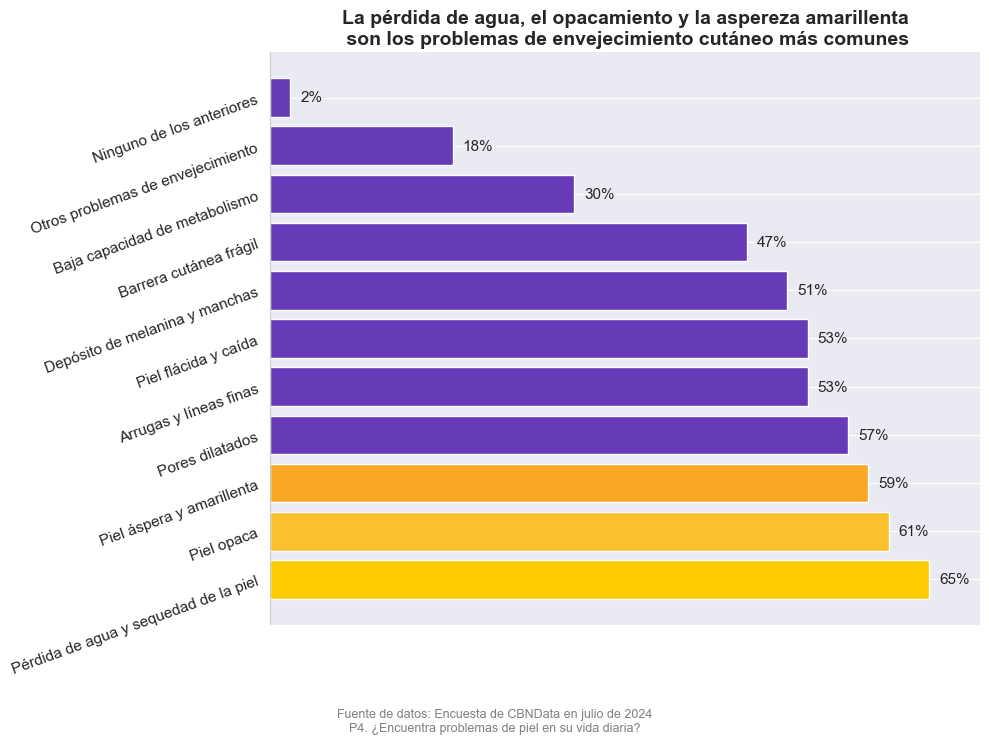

In [2]:
import matplotlib.pyplot as plt

# Configurar los problemas y porcentajes (en el orden del gráfico original, de mayor a menor)
etiquetas = [
    'Pérdida de agua y sequedad de la piel',
    'Piel opaca',
    'Piel áspera y amarillenta',
    'Pores dilatados',
    'Arrugas y líneas finas',
    'Piel flácida y caída',
    'Depósito de melanina y manchas',
    'Barrera cutánea frágil',
    'Baja capacidad de metabolismo',
    'Otros problemas de envejecimiento',
    'Ninguno de los anteriores'
]
porcentajes = [65, 61, 59, 57, 53, 53, 51, 47, 30, 18, 2]

# Definición de colores (los primeros 3 resaltados en dorado, el resto en púrpura uniforme)
colores = ['#FFCC00', '#FBC02D', '#F9A825'] + ['#673AB7'] * (len(etiquetas) - 3)

# Invertir el orden: mostrar de mayor a menor de arriba hacia abajo
etiquetas = etiquetas[::-1]
porcentajes = porcentajes[::-1]
colores = colores[::-1]
pos_y = range(len(etiquetas))

# Crear la gráfica
fig, ax = plt.subplots(figsize=(10, 7))
barras = ax.barh(pos_y, porcentajes, color=colores)

# Agregar etiquetas de porcentaje
for barra, pct in zip(barras, porcentajes):
    ax.text(barra.get_width() + 1, barra.get_y() + barra.get_height() / 2,
            f'{pct}%', va='center', fontsize=11)

# Configuración del estilo de la gráfica
ax.set_yticks(pos_y)
ax.set_yticklabels(etiquetas, fontsize=11, rotation=20)
ax.invert_yaxis()  # El valor máximo arriba
ax.set_xlim(0, 70)
ax.set_title("La pérdida de agua, el opacamiento y la aspereza amarillenta\n son los problemas de envejecimiento cutáneo más comunes", fontsize=14, weight='bold')

# Eliminar bordes y ejes innecesarios
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.xaxis.set_visible(False)

# Aclaración de la fuente de datos
texto_fuente = (
    "Fuente de datos: Encuesta de CBNData en julio de 2024\n"
    "P4. ¿Encuentra problemas de piel en su vida diaria?"
)
plt.figtext(0.5, -0.05, texto_fuente, wrap=True, ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

# 文件: chart_158_2.py

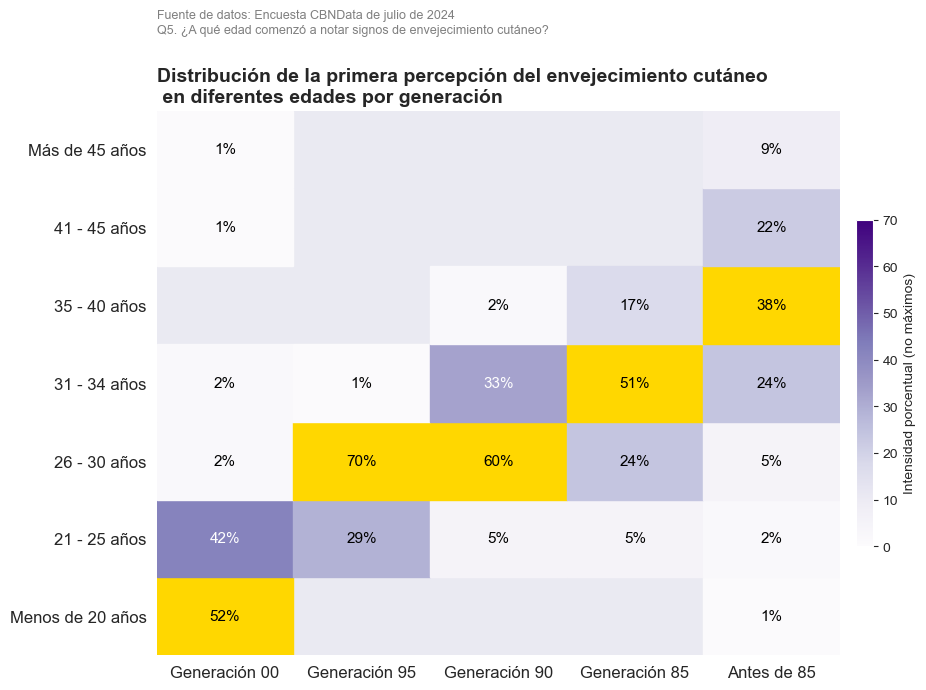

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Etiquetas de las filas y columnas
grupos_edad = ['Menos de 20 años', '21 - 25 años', '26 - 30 años', '31 - 34 años', '35 - 40 años', '41 - 45 años', 'Más de 45 años']
generaciones = ['Generación 00', 'Generación 95', 'Generación 90', 'Generación 85', 'Antes de 85']

# Matriz de porcentajes
datos_porcentaje = np.array([
    [52, 0, 0, 0, 1],
    [42, 29, 5, 5, 2],
    [2, 70, 60, 24, 5],
    [2, 1, 33, 51, 24],
    [0, 0, 2, 17, 38],
    [1, 0, 0, 0, 22],
    [1, 0, 0, 0, 9],
])

# Calcular la posición del valor máximo de cada columna (para resaltar en amarillo)
mascara_resaltado = (datos_porcentaje == np.max(datos_porcentaje, axis = 0))

# Mapeo de colores
cmap = plt.cm.Purples
norm = mcolors.Normalize(vmin = 0, vmax = np.max(datos_porcentaje))

# Preparación de la gráfica
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, len(generaciones))
ax.set_ylim(0, len(grupos_edad))

# Dibujar las celdas
for i in range(len(grupos_edad)):
    for j in range(len(generaciones)):
        valor = datos_porcentaje[i, j]
        if valor > 0:
            if mascara_resaltado[i, j]:
                color = '#FFD700'  # Amarillo para resaltar el valor máximo
                color_texto = 'black'
            else:
                color = cmap(norm(valor))  # Gradiente de morado
                color_texto = 'white' if valor > 30 else 'black'
            ax.add_patch(plt.Rectangle((j, len(grupos_edad)-1 - i), 1, 1, color = color))
            ax.text(j + 0.5, len(grupos_edad)-1 - i + 0.5, f'{valor}%',
                    ha = 'center', va = 'center', fontsize = 11, color = color_texto)

# Establecer las etiquetas de los ejes
ax.set_xticks(np.arange(len(generaciones)) + 0.5)
ax.set_xticklabels(generaciones, fontsize = 12)
ax.set_yticks(np.arange(len(grupos_edad)) + 0.5)
ax.set_yticklabels(grupos_edad[::-1], fontsize = 12)
ax.invert_yaxis()

# Título y fuente de los datos
plt.title('Distribución de la primera percepción del envejecimiento cutáneo\n'
          ' en diferentes edades por generación', fontsize = 14, weight = 'bold', loc = 'left')
plt.text(0, -1, 'Fuente de datos: Encuesta CBNData de julio de 2024\nQ5. ¿A qué edad comenzó a notar signos de envejecimiento cutáneo?',
         fontsize = 9, color = 'gray')

# Limpiar el estilo
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left = False, bottom = False)
plt.grid(False)

# Agregar la barra de colores (solo muestra el mapeo de morado)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm = norm, cmap = cmap),
                    ax = ax, orientation = 'vertical', shrink = 0.6, pad = 0.02)
cbar.set_label('Intensidad porcentual (no máximos)', fontsize = 10)

plt.tight_layout()
plt.show()

# 文件: chart_158_3.py

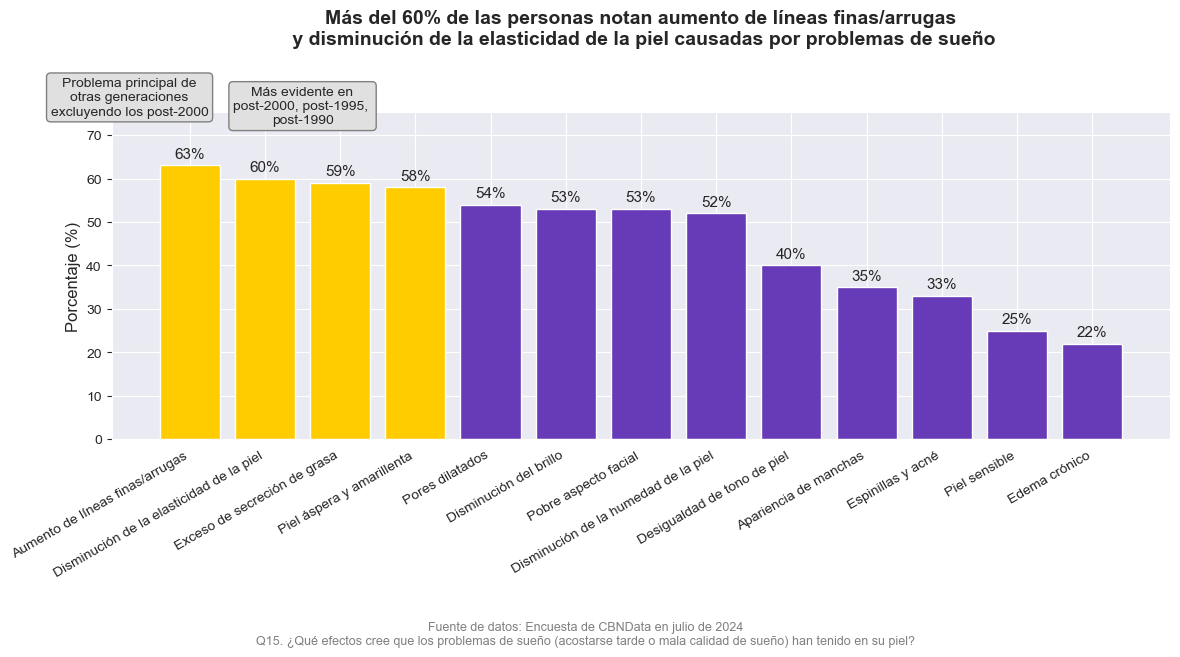

In [7]:
import matplotlib.pyplot as plt

# 数据
etiquetas = [
    'Aumento de líneas finas/arrugas', 'Disminución de la elasticidad de la piel', 'Exceso de secreción de grasa', 'Piel áspera y amarillenta', 'Pores dilatados', 'Disminución del brillo',
    'Pobre aspecto facial', 'Disminución de la humedad de la piel', 'Desigualdad de tono de piel', 'Apariencia de manchas', 'Espinillas y acné', 'Piel sensible', 'Edema crónico'
]
porcentajes = [63, 60, 59, 58, 54, 53, 53, 52, 40, 35, 33, 25, 22]

# Establecer colores
colores = ['#FFCC00' if i < 4 else '#673AB7' for i in range(len(etiquetas))]

x = range(len(etiquetas))
fig, ax = plt.subplots(figsize=(12, 6))
barras = ax.bar(x, porcentajes, color=colores)

# Agregar etiquetas de porcentaje sobre las barras
for i, barra in enumerate(barras):
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura + 1,
            f'{porcentajes[i]}%', ha='center', va='bottom', fontsize=11)

# Establecer etiquetas del eje x
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=10, rotation=30, ha='right')

# Título
ax.set_title('Más del 60% de las personas notan aumento de líneas finas/arrugas\n'
             ' y disminución de la elasticidad de la piel causadas por problemas de sueño',
             fontsize=14, weight='bold',pad=50)

ax.set_ylim(0, 75)
ax.set_ylabel('Porcentaje (%)', fontsize=12)

x_medio = (0 + 1) / 2
ax.text(x_medio-1.3, 74, 'Problema principal de\notras generaciones\nexcluyendo los post-2000',
        ha='center', va='bottom', fontsize=10,
        bbox=dict(facecolor='#E0E0E0', edgecolor='gray', boxstyle='round,pad=0.3'))

ax.text(1.5, 72, 'Más evidente en\npost-2000, post-1995, \npost-1990',
        ha='center', va='bottom', fontsize=10,
        bbox=dict(facecolor='#E0E0E0', edgecolor='gray', boxstyle='round,pad=0.3'))

# Nota al pie de página de la fuente de los datos
plt.figtext(0.5, -0.08,
            'Fuente de datos: Encuesta de CBNData en julio de 2024\nQ15. ¿Qué efectos cree que los problemas de sueño (acostarse tarde o mala calidad de sueño) han tenido en su piel?',
            wrap=True, ha='center', fontsize=9, color='gray')

# Mejorar la apariencia
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', left=True)

plt.tight_layout()
plt.show()

# 文件: chart_158_4.py

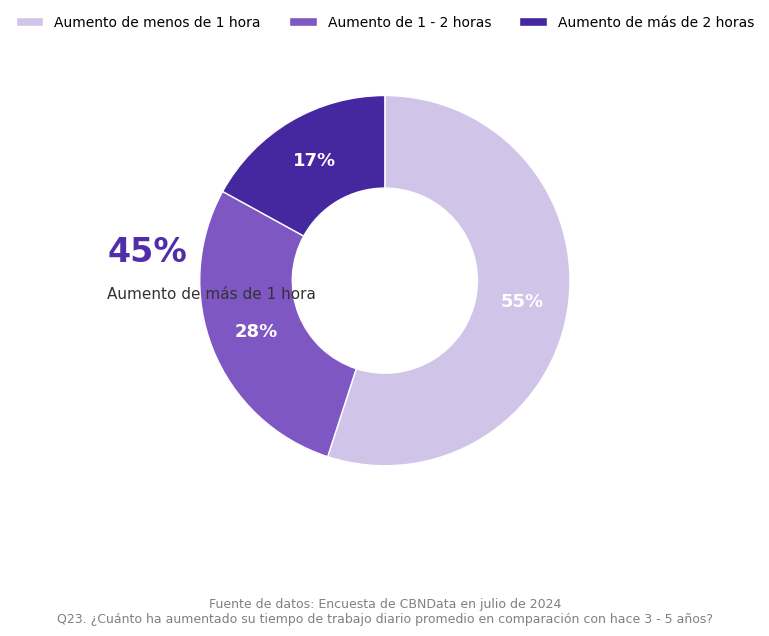

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# 数据
# 翻译为西班牙语：Etiquetas para las secciones del gráfico circular
labels = ['Aumento de menos de 1 hora', 'Aumento de 1 - 2 horas', 'Aumento de más de 2 horas']
# 翻译为西班牙语：Tamaños (porcentajes) de cada sección del gráfico circular
sizes = [55, 28, 17]
# 翻译为西班牙语：Colores para cada sección del gráfico circular
colors = ['#D1C4E9', '#7E57C2', '#4527A0']

# 创建图形
# 翻译为西班牙语：Crear una figura y un eje para el gráfico
fig, ax = plt.subplots(figsize=(7, 6))

# 绘制饼图，使用 autopct 自动显示比例并居中显示
# 翻译为西班牙语：Dibujar un gráfico circular, mostrar automáticamente los porcentajes y centrarlos
wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.5, edgecolor='white'),
    autopct='%1.0f%%',
    pctdistance=0.75
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')

# 左侧文字
# 翻译为西班牙语：Texto en el lado izquierdo del gráfico
ax.text(-1.5, 0.1, '45%', fontsize=24, fontweight='bold', color='#512DA8')
ax.text(-1.5, -0.1, 'Aumento de más de 1 hora', fontsize=11, color='#333333')

# 图例
# 翻译为西班牙语：Leyenda del gráfico
ax.legend(wedges, labels, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3, frameon=False, fontsize=10)

# 数据来源
# 翻译为西班牙语：Fuente de los datos
plt.figtext(
    0.5, -0.1,
    "Fuente de datos: Encuesta de CBNData en julio de 2024\nQ23. ¿Cuánto ha aumentado su tiempo de trabajo diario promedio en comparación con hace 3 - 5 años?",
    wrap=True, ha='center', fontsize=9, color='gray'
)

plt.tight_layout()
plt.show()